# 3. 데이터 분석에서의 벡터

## 벡터로 유사도·필터·군집을 계산하기

- **배울 것**: 코사인 유사도와 상관계수의 차이, 이동 내적, k-means.
- 데이터 열 하나를 벡터로 보면 유사도는 각도, 필터는 작은 벡터와의 내적, 군집은 중심까지의 거리 문제가 됩니다.

$$
\operatorname{cos}(\mathbf x,\mathbf y)=\frac{\mathbf x^T\mathbf y}{\|\mathbf x\|\|\mathbf y\|},\qquad
r=\frac{(\mathbf x-\bar x\mathbf1)^T(\mathbf y-\bar y\mathbf1)}{\|\mathbf x-\bar x\mathbf1\|\|\mathbf y-\bar y\mathbf1\|}
$$

- 상관계수는 **평균을 뺀 뒤의 코사인 유사도**입니다. 절대 수준보다 함께 오르내리는 패턴을 봅니다.
- $x=(0,1,2,3)$, $y=x+10$이면 상관계수는 1입니다. 원점 기준 방향은 변하므로 코사인 유사도는 1보다 작습니다.
- 상수 벡터는 중심화하면 영벡터가 되어 상관계수가 정의되지 않습니다.
- 상관계수 0은 선형 관계가 없다는 뜻입니다. 원형 산점도처럼 비선형 관계는 남아 있을 수 있습니다.

## 필터는 작은 창을 옮기며 계산하는 내적

$$
z_t=\sum_j k_jx_{t+j}
$$

- 커널 `[-1,1]`은 이웃 값의 차이를 구하므로 급격한 변화에 반응합니다. 0에서 1로 올라가는 곳은 양수, 내려가는 곳은 음수가 됩니다.
- 양수 가중치의 합을 1로 맞춘 커널은 주변 평균을 계산해 잡음을 줄입니다.
- 합이 0인 커널은 일정한 밝기나 기준 수준을 제거하고 변화에 집중합니다.
- 원본 루프는 커널을 뒤집지 않는 이동 내적입니다. 일반적인 수학적 합성곱은 커널을 뒤집습니다. 대칭 커널이면 두 방식이 같습니다.
- 경계는 창이 완전히 들어오지 않으므로 패딩하거나 계산 구간을 줄여야 합니다. 원본은 일부 경계를 그대로 남깁니다.

## k-means의 세 단계

$$
J=\sum_{i=1}^N\|\mathbf x_i-\boldsymbol\mu_{c_i}\|_2^2
$$

- ① 중심을 고릅니다. ② 각 점을 가장 가까운 중심에 배정합니다. ③ 배정된 점들의 평균으로 중심을 옮깁니다.
- 제곱거리의 최솟값 위치는 거리의 최솟값 위치와 같으므로 제곱근 없이 배정할 수 있습니다.
- 초기 중심에 따라 다른 국소해에 도달할 수 있습니다. 코드의 3회 반복 그림은 학습 과정이며 수렴을 보장하지 않습니다.
- **주의**: 빈 군집에서는 평균이 `nan`이 됩니다. 실제 구현에서는 재초기화와 종료 조건을 추가해야 합니다.

## 읽기 안내

- 이 글은 제공된 Python 예제를 바탕으로 새로 작성한 해설입니다. 연습문제의 질문은 코드에서 확인되는 학습 목표를 재구성했으며 책의 문제 원문을 옮긴 것이 아닙니다.
- 코드·실행 결과는 아래 순서로 연결됩니다. 앞 셀의 변수를 쓰므로 노트북은 처음부터 실행하세요.
- 난수 시드는 장마다 고정했습니다. 실행 시간과 마지막 소수 자릿수는 환경에 따라 달라질 수 있습니다.
- `1e-14` 같은 작은 잔차는 부동소수점 오차일 수 있습니다. 수학적 0과 컴퓨터의 정확한 0을 구분하세요.

## 실행 환경


In [1]:
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT / 'blog_linear_algebra'
DATA = ROOT / 'data'
ASSET = ROOT / 'assets' / 'ch03'
ASSET.mkdir(parents=True, exist_ok=True)
np.random.seed(20260928)
np.set_printoptions(precision=6, suppress=True, threshold=120)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 140, 'font.size': 12})
print('재현용 난수 시드:', 20260928)

재현용 난수 시드: 20260928


### 코드 03-01

- 원본: `original_py/LA4DS_ch03.py` 1–7행.
- **보완**: Markdown 호환을 위해 그림 출력을 PNG로 지정했습니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png') # print figures in svg format
plt.rcParams.update({'font.size':14}) # set global font size

### 코드 03-02

- 원본: `original_py/LA4DS_ch03.py` 10–64행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

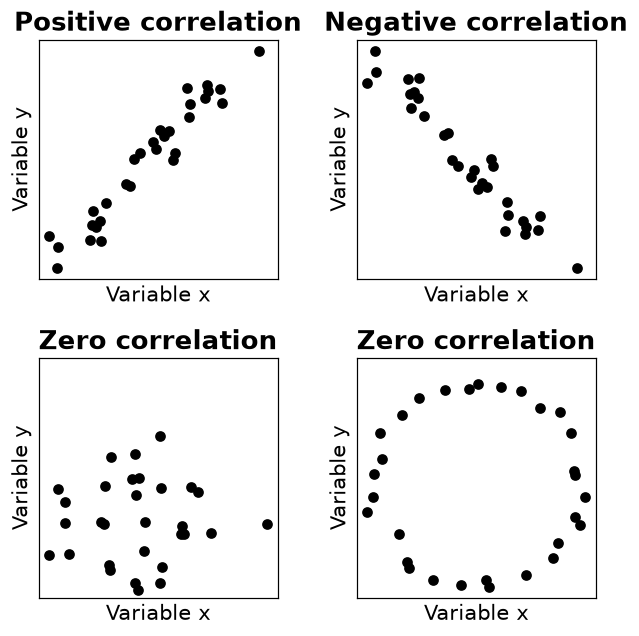

In [3]:
N = 30

# correlated random variables
x = np.linspace(0,10,N) + np.random.randn(N)
y = x + np.random.randn(N)


# set up figure
_,axs = plt.subplots(2,2,figsize=(6,6))

# positive correlation
axs[0,0].plot(x,y,'ko')
axs[0,0].set_title('Positive correlation',fontweight='bold')
axs[0,0].set_xlabel('Variable x')
axs[0,0].set_ylabel('Variable y')
axs[0,0].set_xticks([])
axs[0,0].set_yticks([])
axs[0,0].axis('square')


# negative correlation
axs[0,1].plot(x,-y,'ko')
axs[0,1].set_title('Negative correlation',fontweight='bold')
axs[0,1].set_xlabel('Variable x')
axs[0,1].set_ylabel('Variable y')
axs[0,1].set_xticks([])
axs[0,1].set_yticks([])
axs[0,1].axis('square')


# zero correlation, part 1
axs[1,0].plot(np.random.randn(N),np.random.randn(N),'ko')
axs[1,0].set_title('Zero correlation',fontweight='bold')
axs[1,0].set_xlabel('Variable x')
axs[1,0].set_ylabel('Variable y')
axs[1,0].set_xticks([])
axs[1,0].set_yticks([])
axs[1,0].axis('square')


# zero correlation, part 2
x = np.cos(np.linspace(0,2*np.pi,N)) + np.random.randn(N)/20
y = np.sin(np.linspace(0,2*np.pi,N)) + np.random.randn(N)/20
axs[1,1].plot(x,y,'ko')
axs[1,1].set_title('Zero correlation',fontweight='bold')
axs[1,1].set_xlabel('Variable x')
axs[1,1].set_ylabel('Variable y')
axs[1,1].set_xticks([])
axs[1,1].set_yticks([])
axs[1,1].axis('square')


plt.tight_layout()
plt.savefig(ASSET / 'Figure_03_01.png',dpi=140) # write out the fig to a file
plt.show()

### 코드 03-03

- 원본: `original_py/LA4DS_ch03.py` 68–68행.

In [4]:
### Note: The code for k-means is in Exercise 7 below.

## 연습문제 1 · 상관과 코사인 함수를 구현

- **목표**: 평균 제거가 두 지표를 어떻게 연결하는지 확인합니다.
- **풀이 순서**: 원시 벡터 내적을 노름 곱으로 나누고, 평균을 뺀 벡터에도 같은 계산을 합니다. 상관 결과를 `corrcoef`와 대조합니다.
- **결과 해석**: 직접 구한 상관과 NumPy 상관은 같습니다. 코사인은 일반적으로 다르며 입력의 절대 기준점에 영향을 받습니다.

### 코드 03-04

- 원본: `original_py/LA4DS_ch03.py` 72–98행.

In [5]:
# the function
def corrAndCosine(x,y):

  # compute cosine similarity
  num = np.dot(x,y) # numerator
  den = np.linalg.norm(x) * np.linalg.norm(y) # denominator
  cos = num / den

  # compute correlation (similar to above but mean-centered!)
  xm  = x-np.mean(x)
  ym  = y-np.mean(y)
  num = np.dot(xm,ym) # numerator
  den = np.linalg.norm(xm) * np.linalg.norm(ym) # denominator
  cor = num / den

  return cor,cos


# test it
a = np.random.randn(15)
b = np.random.randn(15)

# compute the correlation and cosine
r,c = corrAndCosine(a,b)

# confirm that the correlation matches with np.corrcoef
print(r,np.corrcoef(a,b)[0,1])

0.04553814617780566 0.045538146177805654


### 코드 03-05

- 원본: `original_py/LA4DS_ch03.py` 100–117행.

In [6]:
# compare r and c without mean-centering
a = np.random.randn(15) + 10 # note the offset!
b = np.random.randn(15)

# mean-center
aNoMean = a - np.mean(a)
bNoMean = b - np.mean(b)


# show the results with and without mean-centering
print('Without mean-centering (should differ):')
print( np.round(corrAndCosine(a,b),4) )
print(' ')

print('With mean-centering (should be the same):')
print( np.round(corrAndCosine(aNoMean,bNoMean),4) )

# NOTE: In the printing code above, I rounded to 4 significant digits just for visual clarity.

Without mean-centering (should differ):
[ 0.096  -0.1235]
 
With mean-centering (should be the same):
[0.096 0.096]


## 연습문제 2 · 평균을 제거한 뒤 비교

- **목표**: 중심화된 벡터에서는 두 지표가 같음을 검증합니다.
- **풀이 순서**: 한 벡터에 큰 평균 오프셋을 넣어 두 지표를 비교한 후 양쪽 평균을 빼고 다시 계산합니다.
- **결과 해석**: 중심화 전의 두 값은 다를 수 있고 중심화 후에는 일치합니다. 상관계수가 중심화된 코사인이라는 공식의 직접 확인입니다.

### 코드 03-06

- 원본: `original_py/LA4DS_ch03.py` 119–143행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

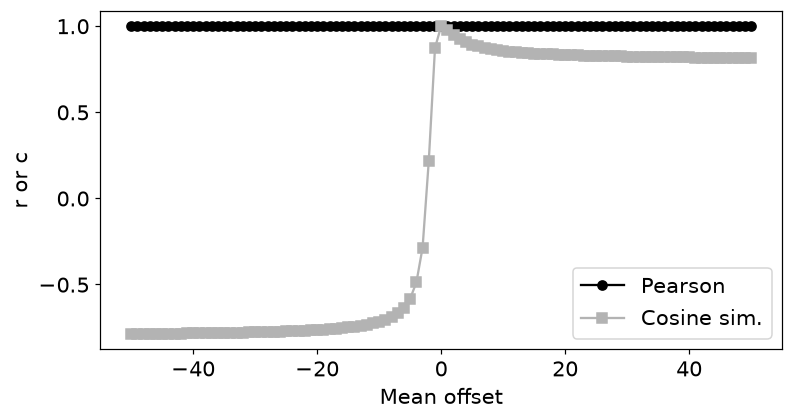

In [7]:
# create the variables
a = np.arange(4,dtype=float)
offsets = np.arange(-50,51)

# initialize the results
results = np.zeros((len(offsets),2))

# run the simulation!
for i in range(len(offsets)):
    results[i,:] = corrAndCosine(a,a+offsets[i])


# plot the results!
plt.figure(figsize=(8,4))
h = plt.plot(offsets,results)
h[0].set_color('k')
h[0].set_marker('o')
h[1].set_color([.7,.7,.7])
h[1].set_marker('s')

plt.xlabel('Mean offset')
plt.ylabel('r or c')
plt.legend(['Pearson','Cosine sim.'])
plt.savefig(ASSET / 'Figure_03_02.png',dpi=140) # write out the fig to a file
plt.show()

## 연습문제 3 · 오프셋 실험

- **목표**: 상관의 이동 불변성을 그림으로 관찰합니다.
- **풀이 순서**: `a`와 `a+offset`을 -50부터 50까지 비교하여 두 유사도를 그립니다.
- **결과 해석**: 상관은 1을 유지하지만 코사인은 달라집니다. 값의 패턴은 같은데 전체 수준만 달라질 때 지표 선택이 중요합니다.

### 코드 03-07

- 원본: `original_py/LA4DS_ch03.py` 147–151행.
- **보완**: IPython 소스 보기 명령을 함수 시그니처와 설명 출력으로 변환했습니다. 전체 소스는 inspect.getsource로 확인할 수 있습니다.

In [8]:
# import the function
from scipy.stats import pearsonr

# inspect the source code
import inspect
print(inspect.signature(pearsonr))
print(inspect.getdoc(pearsonr).split("\n\n")[0])

(x, y, *, alternative='two-sided', method=None, axis=0)
Pearson correlation coefficient and p-value for testing non-correlation.


## 연습문제 4 · 함수 소스와 실행 시간

- **목표**: 간단한 상관 함수와 SciPy 함수의 작업 범위를 구분합니다.
- **풀이 순서**: 시그니처·설명을 확인하고 두 함수를 각각 1000번 호출해 시간을 측정합니다.
- **결과 해석**: 시간은 환경마다 달라집니다. `pearsonr`는 검증과 통계 결과 계산도 수행하므로 단순 상관 함수와 기능이 같다고 결론내릴 수 없습니다. 원본 주석의 corrcoef와 달리 실제 비교 함수는 pearsonr입니다.

### 코드 03-08

- 원본: `original_py/LA4DS_ch03.py` 155–190행.

In [9]:
# a bare-bones correlation function
def rho(x,y):
  xm = x-np.mean(x)
  ym = y-np.mean(y)
  n  = np.dot(xm,ym)
  d  = np.linalg.norm(xm) * np.linalg.norm(ym)
  return n/d


# import the time library
import time

# experiment parameters
numIters  = 1000
varLength =  500

# clock my custom-written function
tic = time.time()
for i in range(numIters):
  x = np.random.randn(varLength,2)
  rho(x[:,0],x[:,1])
t1 = time.time() - tic


# now for numpy's corrcoef function
tic = time.time()
for i in range(numIters):
  x = np.random.randn(varLength,2)
  pearsonr(x[:,0],x[:,1])
t2 = time.time() - tic


# print the results!
# Note: time() returns seconds, so I multiply by 1000 for ms
print(f'My function took {t1*1000:.2f} ms')
print(f'   pearsonr took {t2*1000:.2f} ms')

My function took 26.74 ms
   pearsonr took 222.65 ms


## 연습문제 5 · 변화점 찾기

- **목표**: 차분 커널이 계단 신호의 경계를 검출함을 확인합니다.
- **풀이 순서**: 0–1–0 신호를 만들고 `[-1,1]`과 창별 내적을 계산합니다. 원신호 위에 응답을 표시합니다.
- **결과 해석**: 올라가는 경계는 양수, 내려가는 경계는 음수입니다. 0인 평탄 영역에서는 응답이 없습니다. 창 인덱스에 따라 표시 위치가 한 칸 다를 수 있습니다.

### 코드 03-09

- 원본: `original_py/LA4DS_ch03.py` 194–212행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

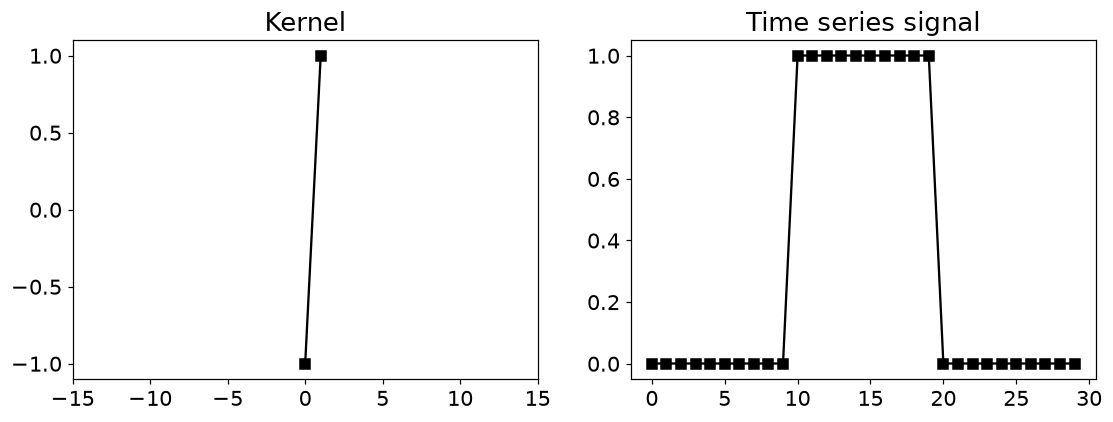

In [10]:
# create the kernel
kernel = np.array([-1,1])

# and the "signal" (a plateau)
signal = np.zeros(30)
signal[10:20] = 1


# plot them
_,axs = plt.subplots(1,2,figsize=(12,4))
axs[0].plot(kernel,'ks-')
axs[0].set_title('Kernel')
axs[0].set_xlim([-15,15])

axs[1].plot(signal,'ks-')
axs[1].set_title('Time series signal')

plt.savefig(ASSET / 'Figure_03_04ab.png',dpi=140)
plt.show()

### 코드 03-10

- 원본: `original_py/LA4DS_ch03.py` 214–239행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

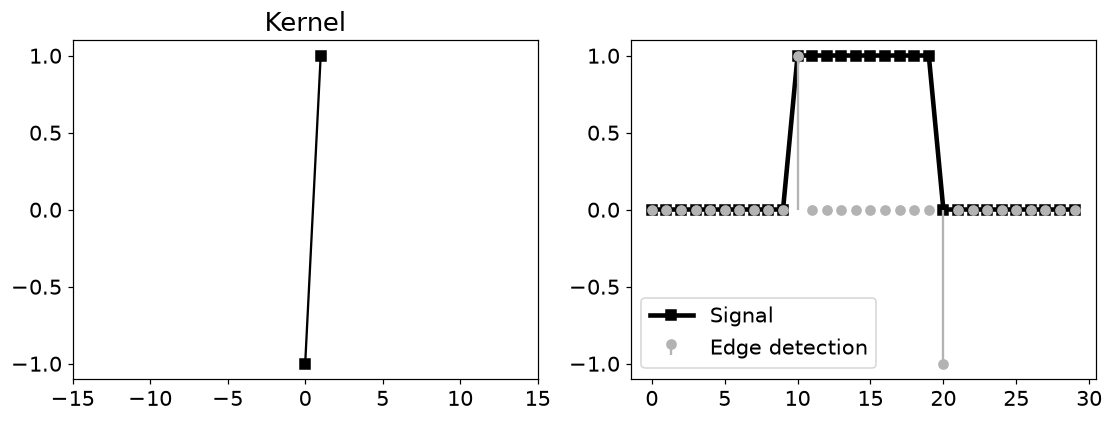

In [11]:
# initialize the feature map as zeros
featureMap = np.zeros(len(signal))

# loop over the signal and do template-matching (via dot products!)
for t in range(1,len(signal)-1):
  featureMap[t] = np.dot(kernel,signal[t-1:t+1])


# plot the result
_,axs = plt.subplots(1,2,figsize=(12,4))
axs[0].plot(kernel,'ks-')
axs[0].set_title('Kernel')
axs[0].set_xlim([-15,15])


axs[1].plot(signal,'ks-',label='Signal',linewidth=3)
markers,stemlines,_ = axs[1].stem(range(len(featureMap)),featureMap,
                                  basefmt=' ',linefmt='',markerfmt='o',
                                  label='Edge detection')

plt.setp(stemlines,'color',[.7,.7,.7])
plt.setp(markers,'color',[.7,.7,.7])

axs[1].legend()
plt.savefig(ASSET / 'Figure_03_04c.png',dpi=140)
plt.show()

## 연습문제 6 · 평활화 필터

- **목표**: 가중 평균으로 고주파 변동을 줄입니다.
- **풀이 순서**: 대칭 양수 커널의 합을 1로 맞추고 난수 신호에 적용합니다. 필터 전후 선을 비교합니다.
- **결과 해석**: 빠른 요동이 완만해집니다. 원본 루프는 경계 일부를 그대로 복사하며 창이 현재 t에 정확히 대칭 정렬된 구현은 아니므로 경계·정렬 조건을 확인하세요.

### 코드 03-11

- 원본: `original_py/LA4DS_ch03.py` 243–267행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

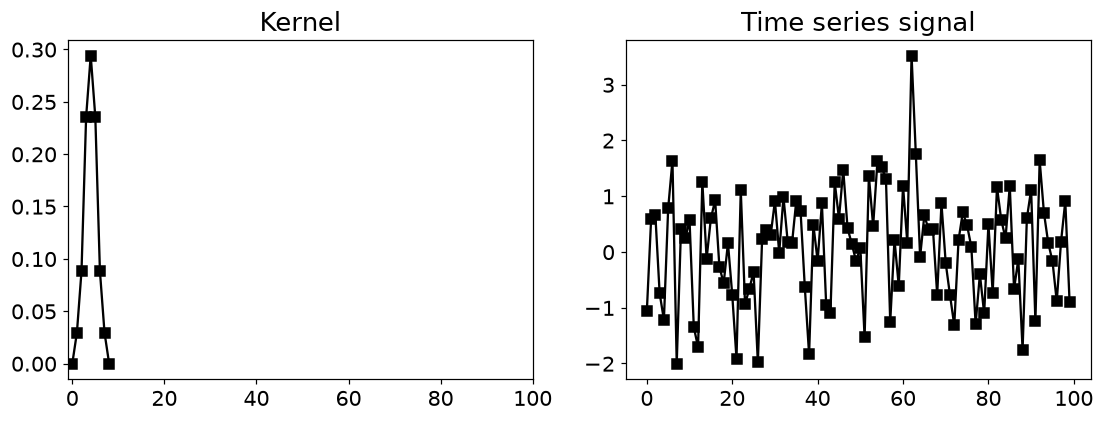

In [12]:
# define the kernel (a sorta-kinda Gaussian)
kernel = np.array([0,.1,.3,.8,1,.8,.3,.1,0])
kernel = kernel / np.sum(kernel)

# some handy length parameters
Nkernel = len(kernel)
halfKrn = Nkernel//2


# and the signal
Nsignal = 100
timeseries = np.random.randn(Nsignal)


# plot them
_,axs = plt.subplots(1,2,figsize=(12,4))
axs[0].plot(kernel,'ks-')
axs[0].set_title('Kernel')
axs[0].set_xlim([-1,Nsignal])

axs[1].plot(timeseries,'ks-')
axs[1].set_title('Time series signal')

plt.savefig(ASSET / 'Figure_03_06ab.png',dpi=140)
plt.show()

### 코드 03-12

- 원본: `original_py/LA4DS_ch03.py` 269–288행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

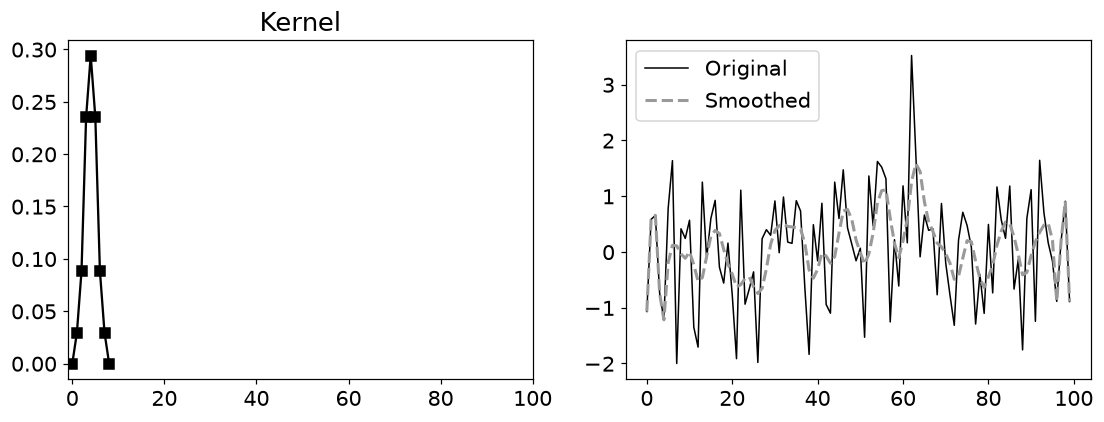

In [13]:
# make a copy of the signal for filtering
filtsig = timeseries.copy()

# loop over the signal time points
for t in range(halfKrn+1,Nsignal-halfKrn):
  filtsig[t] = np.dot(kernel,timeseries[t-halfKrn-1:t+halfKrn])


# and plot
_,axs = plt.subplots(1,2,figsize=(12,4))
axs[0].plot(kernel,'ks-')
axs[0].set_title('Kernel')
axs[0].set_xlim([-1,Nsignal])

axs[1].plot(timeseries,color='k',label='Original',linewidth=1)
axs[1].plot(filtsig,'--',color=[.6,.6,.6],label='Smoothed',linewidth=2)
axs[1].legend()

plt.savefig(ASSET / 'Figure_03_06c.png',dpi=140)
plt.show()

## 연습문제 7 · 합이 0인 커널

- **목표**: 평균 성분을 제거하고 변화에 민감한 응답을 만듭니다.
- **풀이 순서**: 커널 중앙값을 음수로 바꾼 다음 정규화하고 커널 평균을 빼 합을 0으로 만듭니다. 같은 신호에 적용합니다.
- **결과 해석**: 응답은 원신호의 밝기 수준보다 변화에 반응합니다. 이를 원본에 더하는 처리가 없으므로 ‘선명해진 신호’라는 이름만 보고 원신호를 그대로 보존한다고 해석하지 않습니다.

### 코드 03-13

- 원본: `original_py/LA4DS_ch03.py` 290–315행.

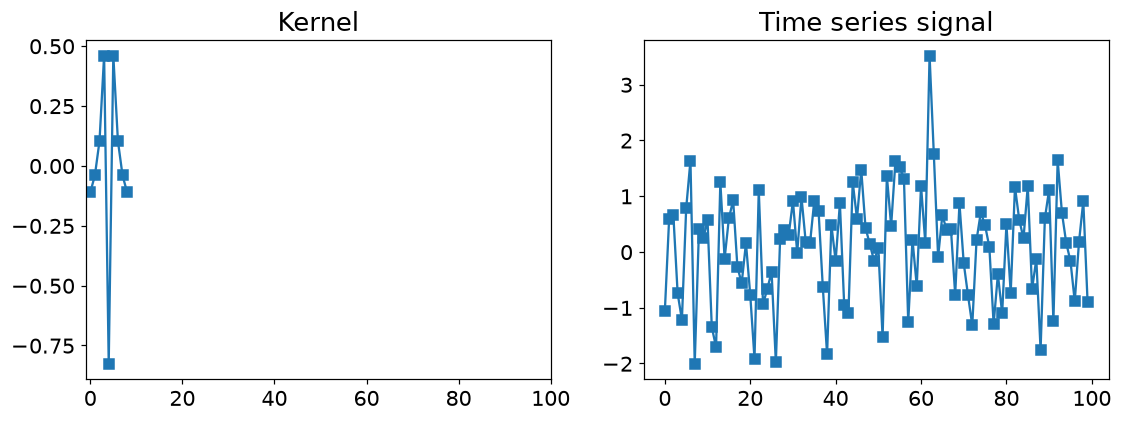

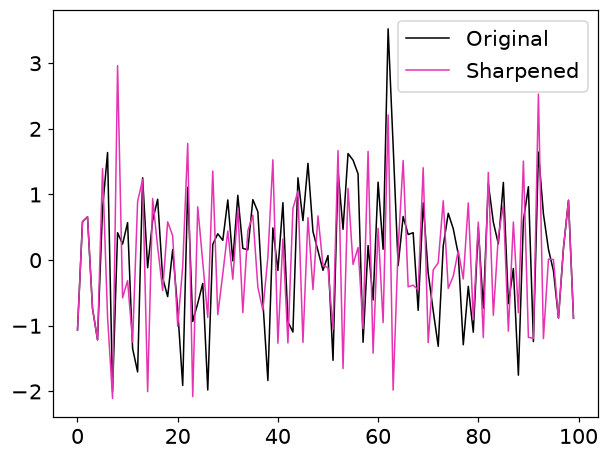

In [14]:
# define the kernel (a sorta-kinda Gaussian)
kernel = np.array([0,.1,.3,.8,-1,.8,.3,.1,0])
kernel /= np.sum(kernel)
kernel -= np.mean(kernel)

# plot them
_,axs = plt.subplots(1,2,figsize=(12,4))
axs[0].plot(kernel,'s-')
axs[0].set_title('Kernel')
axs[0].set_xlim([-1,Nsignal])

axs[1].plot(timeseries,'s-')
axs[1].set_title('Time series signal')
plt.show()



# loop over the signal time points
filtsig2 = timeseries.copy()
for t in range(halfKrn+1,Nsignal-halfKrn):
  filtsig2[t] = np.dot(kernel,timeseries[t-halfKrn-1:t+halfKrn])

plt.plot(timeseries,color='k',label='Original',linewidth=1)
plt.plot(filtsig2,color=[.9,.2,.7],label='Sharpened',linewidth=1)
plt.legend()
plt.show()

## 연습문제 8 · k-means 직접 구현

- **목표**: 거리 계산·군집 배정·중심 갱신을 연결합니다.
- **풀이 순서**: 세 덩어리의 난수 점을 만들고 데이터에서 초기 중심을 선택합니다. 제곱거리 최솟값으로 배정한 후 군집별 평균으로 중심을 바꾸는 과정을 3회 반복합니다.
- **결과 해석**: 중심이 데이터 덩어리 쪽으로 이동합니다. 최종 그림은 이 초기값에서의 3회 결과이며 최적·수렴을 증명하지 않습니다. 빈 군집과 종료 조건은 실제 구현의 추가 과제입니다.

### 코드 03-14

- 원본: `original_py/LA4DS_ch03.py` 319–345행.

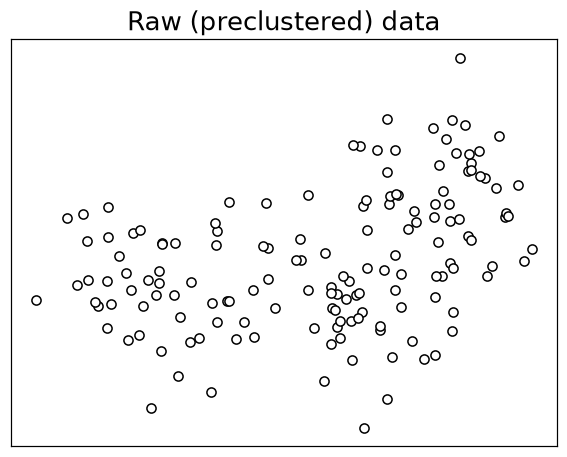

In [15]:
## Create data
nPerClust = 50

# blur around centroid (std units)
blur = 1

# XY centroid locations
A = [  1, 1 ]
B = [ -3, 1 ]
C = [  3, 3 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur , C[1]+np.random.randn(nPerClust)*blur ]

# concatanate into a matrix
data = np.transpose( np.concatenate((a,b,c),axis=1) )


# plot data
plt.plot(data[:,0],data[:,1],'ko',markerfacecolor='w')
plt.title('Raw (preclustered) data')
plt.xticks([])
plt.yticks([])

plt.show()

### 코드 03-15

- 원본: `original_py/LA4DS_ch03.py` 347–396행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

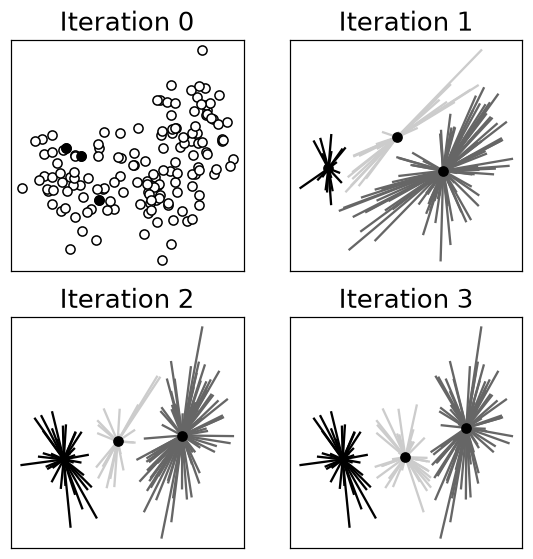

In [16]:
## initialize random cluster centroids
k = 3 # extract three clusters

# random cluster centers (randomly sampled data points)
ridx = np.random.choice(range(len(data)),k,replace=False)
centroids = data[ridx,:]


# setup the figure
fig,axs = plt.subplots(2,2,figsize=(6,6))
axs = axs.flatten()
lineColors = [ [0,0,0],[.4,.4,.4],[.8,.8,.8] ]#'rbm'


# plot data with initial random cluster centroids
axs[0].plot(data[:,0],data[:,1],'ko',markerfacecolor='w')
axs[0].plot(centroids[:,0],centroids[:,1],'ko')
axs[0].set_title('Iteration 0')
axs[0].set_xticks([])
axs[0].set_yticks([])



# loop over iterations
for iteri in range(3):
    
  # step 1: compute distances
  dists = np.zeros((data.shape[0],k))
  for ci in range(k):
    dists[:,ci] = np.sum((data-centroids[ci,:])**2,axis=1)
        
  # step 2: assign to group based on minimum distance
  groupidx = np.argmin(dists,axis=1)
    
  # step 3: recompute centers
  for ki in range(k):
    centroids[ki,:] = [ np.mean(data[groupidx==ki,0]), np.mean(data[groupidx==ki,1]) ]
  

  # plot data points
  for i in range(len(data)):
    axs[iteri+1].plot([ data[i,0],centroids[groupidx[i],0] ],[ data[i,1],centroids[groupidx[i],1] ],color=lineColors[groupidx[i]])
  axs[iteri+1].plot(centroids[:,0],centroids[:,1],'ko')
  axs[iteri+1].set_title(f'Iteration {iteri+1}')
  axs[iteri+1].set_xticks([])
  axs[iteri+1].set_yticks([])


plt.savefig(ASSET / 'Figure_03_03.png',dpi=140)
plt.show()

## 핵심 결과 다시 확인하기

- 아래는 원본과 별도로 추가한 작은 검증 예제입니다.
- `assert`가 통과하면 해당 수학적 관계가 지정한 수치 허용오차 안에서 성립한 것입니다.
- 큰 예제의 숫자를 외우기보다 이 관계가 왜 성립하는지 설명해 보세요.

In [17]:
_x=np.arange(4.); _y=_x+10
_cos=_x@_y/(np.linalg.norm(_x)*np.linalg.norm(_y))
_r=np.corrcoef(_x,_y)[0,1]
print('상관:',_r,'코사인:',round(_cos,6))
assert np.isclose(_r,1) and _cos<1
_d=np.diff(np.r_[np.zeros(3),np.ones(3),np.zeros(3)])
print('계단 신호 차분:',_d)
assert np.array_equal(_d,[0,0,1,0,0,-1,0,0])


상관: 1.0 코사인: 0.855849
계단 신호 차분: [ 0.  0.  1.  0.  0. -1.  0.  0.]
